# Exploración del modelo
## Aprendizaje Profundo - PCIC
### Eduardo García Alarcón 2025-1

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import speechbrain as sb
import torch as th
from tqdm import tqdm, trange
import torchaudio

SEED = 42
np.random.seed(SEED)
th.manual_seed(SEED)

/home/edu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/edu/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []


In [2]:
from speechbrain.inference.classifiers import EncoderClassifier
classifier = EncoderClassifier.from_hparams(source="speechbrain/urbansound8k_ecapa", savedir="pretrained_models/gurbansound8k_ecapa")

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch custom.py: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch embedding_model.ckpt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch classifier.ckpt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.fetching:Fetch label_encoder.txt: Fetching from HuggingFace Hub 'speechbrain/urbansound8k_ecapa' if not cached
INFO:speechbrain.utils.parameter_transfer:Loading pretrained files for: embedding_model, classifier, label_encoder


In [3]:
classifier.modules

<bound method Module.modules of EncoderClassifier(
  (mods): ModuleDict(
    (compute_features): Fbank(
      (compute_STFT): STFT()
      (compute_fbanks): Filterbank()
      (compute_deltas): Deltas()
      (context_window): ContextWindow()
    )
    (mean_var_norm): InputNormalization()
    (embedding_model): ECAPA_TDNN(
      (blocks): ModuleList(
        (0): TDNNBlock(
          (conv): Conv1d(
            (conv): Conv1d(80, 1024, kernel_size=(5,), stride=(1,))
          )
          (activation): ReLU()
          (norm): BatchNorm1d(
            (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          )
        )
        (1): SERes2NetBlock(
          (tdnn1): TDNNBlock(
            (conv): Conv1d(
              (conv): Conv1d(1024, 1024, kernel_size=(1,), stride=(1,))
            )
            (activation): ReLU()
            (norm): BatchNorm1d(
              (norm): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running

## Obtenemos el data set
### AudioSet

In [4]:
import os
import pandas as pd
from yt_dlp import YoutubeDL

In [5]:
from audioset_download import Downloader

ModuleNotFoundError: No module named 'audioset_download'

In [ ]:
help(Downloader)

### Clases de UrbanSound
- 0 = dog_bark
- 1 = children_playing
- 2 = air_conditioner
- 3 = street_music
- 4 = gun_shot
- 5 = siren
- 6 = engine_idling
- 7 = jackhammer
- 8 = drilling
- 9 = car_horn

In [6]:
lable_to_code = {
  'Bark': '/m/05tny_', 
  'Children playing': '/t/dd00013',
  'Air conditioning': '/m/025wky1',
  # 'Music',
  'Gunshot, gunfire': '/m/032s66',
  'Police car (siren)': '/m/04qvtq', 'Ambulance (siren)': '/m/012n7d',
  'Engine': '/m/02mk9',
  'Jackhammer': '/m/03p19w',
  'Drill': '/m/01d380',
  'Vehicle horn, car horn, honking': '/m/0912c9',
}

In [ ]:
d = Downloader('./Data/AudioSet/', labels=[key for key in lable_to_code.keys()], n_jobs=3, download_type='balanced_train', copy_and_replicate=False)

In [7]:
code_to_lable  = {item: key for key, item in lable_to_code.items()}

In [8]:
code_to_lable

{'/m/05tny_': 'Bark',
 '/t/dd00013': 'Children playing',
 '/m/025wky1': 'Air conditioning',
 '/m/032s66': 'Gunshot, gunfire',
 '/m/04qvtq': 'Police car (siren)',
 '/m/012n7d': 'Ambulance (siren)',
 '/m/02mk9': 'Engine',
 '/m/03p19w': 'Jackhammer',
 '/m/01d380': 'Drill',
 '/m/0912c9': 'Vehicle horn, car horn, honking'}

In [9]:
code_to_indx = {key: i for i, key in enumerate(code_to_lable.keys())}

In [10]:
indx_to_lable = {}
for code, indx in code_to_indx.items():
    indx_to_lable[indx] = code_to_lable[code]

In [11]:
indx_to_lable

{0: 'Bark',
 1: 'Children playing',
 2: 'Air conditioning',
 3: 'Gunshot, gunfire',
 4: 'Police car (siren)',
 5: 'Ambulance (siren)',
 6: 'Engine',
 7: 'Jackhammer',
 8: 'Drill',
 9: 'Vehicle horn, car horn, honking'}

In [12]:
code_to_indx.items()

dict_items([('/m/05tny_', 0), ('/t/dd00013', 1), ('/m/025wky1', 2), ('/m/032s66', 3), ('/m/04qvtq', 4), ('/m/012n7d', 5), ('/m/02mk9', 6), ('/m/03p19w', 7), ('/m/01d380', 8), ('/m/0912c9', 9)])

In [13]:
code_to_indx

{'/m/05tny_': 0,
 '/t/dd00013': 1,
 '/m/025wky1': 2,
 '/m/032s66': 3,
 '/m/04qvtq': 4,
 '/m/012n7d': 5,
 '/m/02mk9': 6,
 '/m/03p19w': 7,
 '/m/01d380': 8,
 '/m/0912c9': 9}

In [14]:
codes = [key for key in code_to_lable.keys()]

In [15]:
codes

['/m/05tny_',
 '/t/dd00013',
 '/m/025wky1',
 '/m/032s66',
 '/m/04qvtq',
 '/m/012n7d',
 '/m/02mk9',
 '/m/03p19w',
 '/m/01d380',
 '/m/0912c9']

### Abrimos los CSV
Checamos que los archivos estén descargados

In [46]:
df_val = pd.read_csv(
  'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/eval_segments.csv',
	delimiter=', ',
	header=2)
    
df_train = pd.read_csv(
  'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/balanced_train_segments.csv',
  delimiter=', ',
	header=2)
    
df_train_unbalanced = pd.read_csv(
  'http://storage.googleapis.com/us_audioset/youtube_corpus/v1/csv/unbalanced_train_segments.csv',
  delimiter=', ',
	header=2)

/tmp/ipykernel_96217/1454075283.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_val = pd.read_csv(
/tmp/ipykernel_96217/1454075283.py:6: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_train = pd.read_csv(
/tmp/ipykernel_96217/1454075283.py:11: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df_train_unbalanced = pd.read_csv(


In [47]:
df_train.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,--PJHxphWEs,30.0,40.0,"""/m/09x0r,/t/dd00088"""
1,--ZhevVpy1s,50.0,60.0,"""/m/012xff"""
2,--aE2O5G5WE,0.0,10.0,"""/m/03fwl,/m/04rlf,/m/09x0r"""
3,--aO5cdqSAg,30.0,40.0,"""/t/dd00003,/t/dd00005"""
4,--aaILOrkII,200.0,210.0,"""/m/032s66,/m/073cg4"""


In [48]:
df_train_unbalanced.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,---1_cCGK4M,0.0,10.0,"""/m/01g50p,/m/0284vy3,/m/06d_3,/m/07jdr,/m/07r..."
1,---2_BBVHAA,30.0,40.0,"""/m/09x0r"""
2,---B_v8ZoBY,30.0,40.0,"""/m/04rlf"""
3,---EDNidJUA,30.0,40.0,"""/m/02qldy,/m/02zsn,/m/05zppz,/m/09x0r"""
4,---N4cFAE1A,21.0,31.0,"""/m/04rlf,/m/09x0r"""


In [49]:
df_val.head()

,# YTID,start_seconds,end_seconds,positive_labels
0,--4gqARaEJE,0.0,10.0,"""/m/068hy,/m/07q6cd_,/m/0bt9lr,/m/0jbk"""
1,--BfvyPmVMo,20.0,30.0,"""/m/03l9g"""
2,--U7joUcTCo,0.0,10.0,"""/m/01b_21"""
3,--i-y1v8Hy8,0.0,9.0,"""/m/04rlf,/m/09x0r,/t/dd00004,/t/dd00005"""
4,-0BIyqJj9ZU,30.0,40.0,"""/m/07rgt08,/m/07sq110,/t/dd00001"""


In [50]:
df_train['valid'] = df_train['positive_labels'].apply(lambda x: any(code in x for code in codes) if x else False)

In [51]:
df_train_unbalanced['valid'] = df_train_unbalanced['positive_labels'].apply(lambda x: any(code in x for code in codes) if x else False)

In [52]:
df_val['valid'] = df_val['positive_labels'].apply(lambda x: any(code in x for code in codes) if x else False)

In [53]:
df_train[df_train.valid].valid.sum()

818

In [54]:
df_train_unbalanced[df_train_unbalanced.valid].valid.sum()

33534

In [55]:
df_val[df_val.valid].valid.sum()

816

## Usaremos los datos de unbalanced y extraeremos solo las 10 clases relevantes
Y haremos el split de los datos para con 80% entrenamiento y 20% entrenamiento 

In [56]:
df = df_train_unbalanced[df_train_unbalanced.valid].copy()

In [57]:
df

,# YTID,start_seconds,end_seconds,positive_labels,valid
62,--330hg-Ocw,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00066,/t/dd00130""",True
154,--8puiAGLhs,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00130""",True
226,--Dxk606LRQ,30.0,40.0,"""/m/02mk9""",True
233,--EG-JqO4S0,30.0,40.0,"""/m/02mk9,/m/07pb8fc,/m/07q2z82,/m/09x0r,/t/dd...",True
291,--HXYSM3ydo,2.0,12.0,"""/m/0912c9,/m/09x0r""",True
...,...,...,...,...,...
2041683,zzkzKKRJPi0,10.0,20.0,"""/m/01d380,/m/07k1x""",True
2041687,zzlfP-snUeY,10.0,20.0,"""/m/02mk9,/m/07pb8fc,/m/07yv9,/t/dd00129""",True
2041716,zzoatmX_Xh8,60.0,70.0,"""/m/01jwx6,/m/02mk9,/t/dd00067""",True
2041768,zzx-lGzV5dE,30.0,40.0,"""/m/03kmc9,/m/04qvtq,/m/04rlf""",True


#### Creamos una columna para las categorías

In [58]:
code_to_indx

{'/m/05tny_': 0,
 '/t/dd00013': 1,
 '/m/025wky1': 2,
 '/m/032s66': 3,
 '/m/04qvtq': 4,
 '/m/012n7d': 5,
 '/m/02mk9': 6,
 '/m/03p19w': 7,
 '/m/01d380': 8,
 '/m/0912c9': 9}

In [59]:
code_to_indx.get('/t/dd00013')

1

In [60]:
df['indx'] = df['positive_labels'].apply(lambda x: next((code_to_indx.get(code) for code in codes if code in x), None) if pd.notnull(x) else None)

In [61]:
df

,# YTID,start_seconds,end_seconds,positive_labels,valid,indx
62,--330hg-Ocw,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00066,/t/dd00130""",True,6
154,--8puiAGLhs,30.0,40.0,"""/m/02mk9,/m/07yv9,/m/0k4j,/t/dd00130""",True,6
226,--Dxk606LRQ,30.0,40.0,"""/m/02mk9""",True,6
233,--EG-JqO4S0,30.0,40.0,"""/m/02mk9,/m/07pb8fc,/m/07q2z82,/m/09x0r,/t/dd...",True,6
291,--HXYSM3ydo,2.0,12.0,"""/m/0912c9,/m/09x0r""",True,9
...,...,...,...,...,...,...
2041683,zzkzKKRJPi0,10.0,20.0,"""/m/01d380,/m/07k1x""",True,8
2041687,zzlfP-snUeY,10.0,20.0,"""/m/02mk9,/m/07pb8fc,/m/07yv9,/t/dd00129""",True,6
2041716,zzoatmX_Xh8,60.0,70.0,"""/m/01jwx6,/m/02mk9,/t/dd00067""",True,6
2041768,zzx-lGzV5dE,30.0,40.0,"""/m/03kmc9,/m/04qvtq,/m/04rlf""",True,4


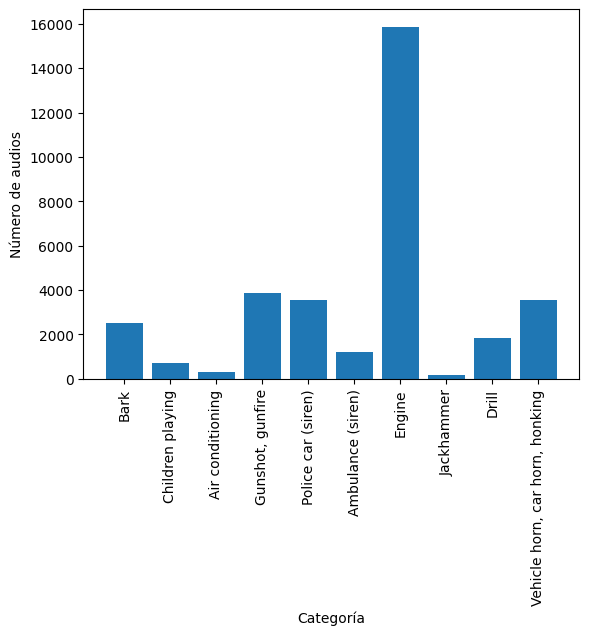

In [62]:
idx, cuentas = np.unique(df.indx, return_counts=True)
plt.bar(x=[indx_to_lable[indx] for indx in idx], height=cuentas)
plt.xticks(rotation=90)
plt.xlabel('Categoría')
plt.ylabel('Número de audios')
plt.show()

In [63]:
from sklearn.model_selection import train_test_split

In [64]:
df_train, df_val = train_test_split(df, test_size=.2, random_state=SEED, shuffle=True, stratify=df.indx)

In [65]:
df_train.shape

(26827, 6)

In [66]:
df_val.shape

(6707, 6)

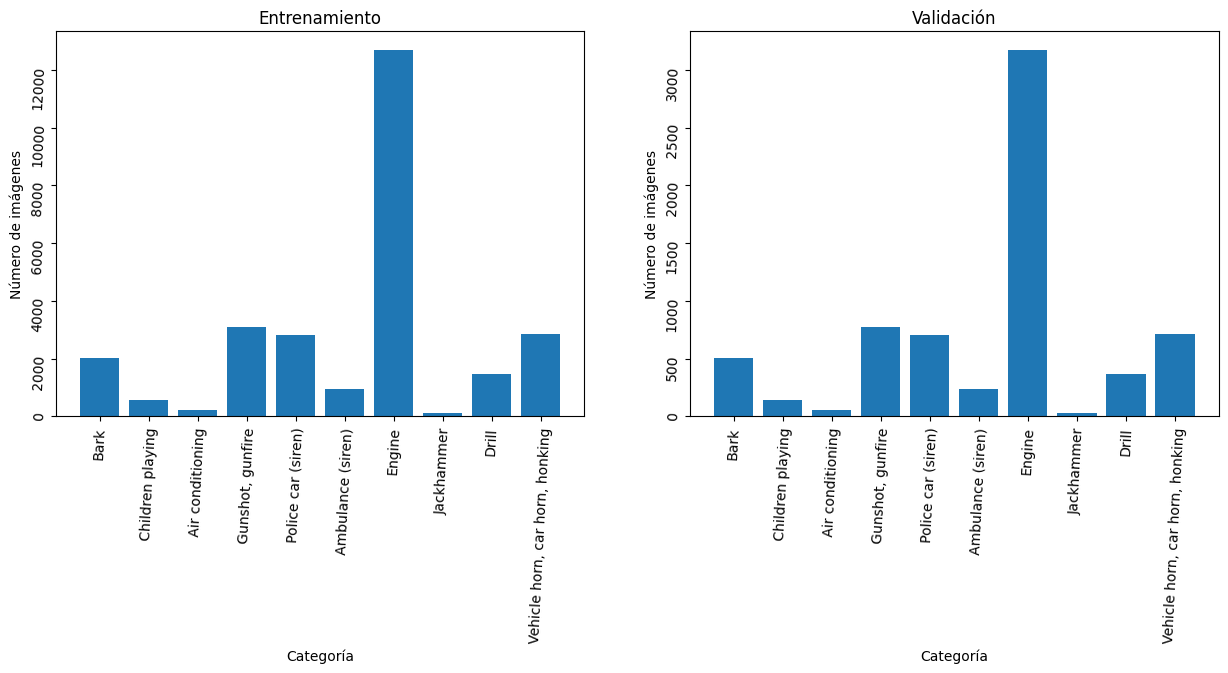

In [67]:
idx_ent, cuentas_ent = np.unique(df_train.indx, return_counts=True)
idx_val, cuentas_val = np.unique(df_val.indx, return_counts=True)

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

axs[0].bar(x=[indx_to_lable[indx] for indx in idx_ent], height=cuentas_ent)
axs[0].set_title('Entrenamiento')
axs[0].set_xlabel('Categoría')
axs[0].set_ylabel('Número de imágenes')
axs[0].tick_params(rotation=87)

axs[1].bar(x=[indx_to_lable[indx] for indx in idx_val], height=cuentas_val)
axs[1].set_title('Validación')
axs[1].set_xlabel('Categoría')
axs[1].set_ylabel('Número de imágenes')
axs[1].tick_params(rotation=87)

plt.show()

## Descargamos los datos

In [68]:
root = './AudioSet/'

In [69]:
import subprocess

In [70]:
def download_and_trim_audio(video_id, start, end, output_dir):
    # Checamos que existe el archivo 
    os.makedirs(output_dir, exist_ok=True)
    
    # Definimos el url de busqueda
    url = f"https://www.youtube.com/watch?v={video_id}"
    
    # Archivo temporal
    temp_file = os.path.join(output_dir, f"{video_id}.mp3")
    
    # Archivo de salida
    output_file = os.path.join(output_dir, f"{video_id}.wav")
    
    # yt-dlp opciones
    ydl_opts = {
        'format': 'bestaudio/best',  
        'outtmpl': temp_file,        
        'quiet': True                
    }
    
    # Descargamos el audio
    with YoutubeDL(ydl_opts) as ydl:
        try:
            ydl.download([url])
        except Exception as e:
            print(f"Failed to download {video_id}: {e}")
            return
    
    # Se recorta y se convierte a wav
    try:
        subprocess.run(
            [
                "ffmpeg",
                "-i", temp_file,      # Archivo de entrada
                "-ss", str(start),    # Inicio
                "-to", str(end),      # Final
                "-c:a", "pcm_s16le",  # WAV 
                "-ar", "16000",       # Sample rate
                "-ac", "1",           # Mono 
                output_file           # Archivo de salida
            ],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

    except Exception as e:
        print(f"No se pudo recordar el video {video_id}: {e}")
    finally:
        # Eliminamos el archivo temporal
        if os.path.exists(temp_file):
            os.remove(temp_file)

In [71]:
test = df_train.iloc[10]

video_id 	= test['# YTID']
start 		= test['start_seconds']
end   		= test['end_seconds']

outputDir = './Data/AudioSet/train/'

print(f'{video_id = }, {start = }, {end = }, {outputDir = }')

video_id = 'StL9pFzRYEc', start = 9.0, end = 19.0, outputDir = './Data/AudioSet/train/'


In [72]:
download_and_trim_audio(video_id=video_id, start=start, end=end, output_dir=outputDir)

In [ ]:
outputDir = './Data/AudioSet/train/'
for _, row in df_train.iterrows():
    video_id, start, end = row['YTID'], row['start_seconds'], row['end_seconds']
    try:
        download_and_trim_audio(video_id, start, end, outputDir)
    except Exception as e:
        print(f"Error procesando video {video_id}: {e}")

In [ ]:
outputDir = './Data/AudioSet/val/'
for _, row in df_val.iterrows():
    video_id, start, end = row['YTID'], row['start_seconds'], row['end_seconds']
    try:
        download_and_trim_audio(video_id, start, end, outputDir)
    except Exception as e:
        print(f"Error procesando video {video_id}: {e}")

### DataLoader

In [74]:
from torch.utils.data import Dataset

In [75]:
class AudioLoader(Dataset):
    def __init__(self, df, transform=None):
        self.df = df
        self.transform = transform
        
    def __getitem__(self, idx):
        #
        pass